# Student Engagement Analysis Visualizations

This notebook visualizes the outputs from the Student Behaviour Analysis pipeline, including emotion distribution, score trends, model-related summary metrics, and feature relationships.

## 1. Import Libraries

Import the required libraries for data loading, visualization, and file management.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Theme
PRIMARY_COLOR = "#0e2941"
PALETTE = ["#0e2941", "#4c6a85", "#7f9bb3", "#b3c7d9"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Configure Paths

The path setup below works whether the notebook is executed from the project root or from the `visualizations/` folder.

In [2]:
PROJECT_ROOT = Path.cwd()

# If notebook is executed from visualizations/, move one level up
if PROJECT_ROOT.name == "visualizations":
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_DIR = PROJECT_ROOT / "outputs" / "csv"
VIS_DIR = PROJECT_ROOT / "outputs" / "visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("CSV directory:", CSV_DIR)
print("Visualization output directory:", VIS_DIR)

Project root: /Users/sakthiselvi/Documents/Projects/Masters/Course 10 Capstone Project/Student_Behaviour_Analysis
CSV directory: /Users/sakthiselvi/Documents/Projects/Masters/Course 10 Capstone Project/Student_Behaviour_Analysis/outputs/csv
Visualization output directory: /Users/sakthiselvi/Documents/Projects/Masters/Course 10 Capstone Project/Student_Behaviour_Analysis/outputs/visualizations


## 3. Load Dataset

Load all CSV files generated by the CV and ML pipelines.

In [3]:
required_files = {
    "emotion": "emotion.csv",
    "gaze": "gaze.csv",
    "gesture": "gesture.csv",
    "pose": "pose.csv",
    "final": "final_combined.csv",
    "summary": "student_summary.csv",
}

missing_files = [name for name in required_files.values() if not (CSV_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing CSV files in {CSV_DIR}: {missing_files}")

emotion_df = pd.read_csv(CSV_DIR / required_files["emotion"])
gaze_df = pd.read_csv(CSV_DIR / required_files["gaze"])
gesture_df = pd.read_csv(CSV_DIR / required_files["gesture"])
pose_df = pd.read_csv(CSV_DIR / required_files["pose"])
final_df = pd.read_csv(CSV_DIR / required_files["final"])
summary_df = pd.read_csv(CSV_DIR / required_files["summary"])

print("Data loaded successfully!")
print(f"Emotion data shape: {emotion_df.shape}")
print(f"Gaze data shape: {gaze_df.shape}")
print(f"Gesture data shape: {gesture_df.shape}")
print(f"Pose data shape: {pose_df.shape}")
print(f"Final combined data shape: {final_df.shape}")
print(f"Summary data shape: {summary_df.shape}")

Data loaded successfully!
Emotion data shape: (381, 6)
Gaze data shape: (381, 8)
Gesture data shape: (381, 7)
Pose data shape: (381, 6)
Final combined data shape: (586, 27)
Summary data shape: (3, 5)


## 4. Data Quality Check

Quickly inspect missing values and available columns.

In [4]:
print("Final dataframe columns:")
print(final_df.columns.tolist())

print("Summary dataframe columns:")
print(summary_df.columns.tolist())

print("Missing values in final dataframe:")
print(final_df.isna().sum())

Final dataframe columns:
['frame', 'student_id', 'joint_visual_attention', 'individual_attention', 'looking_other_student', 'looking_away', 'head_nod_shake', 'confidence', 'head_action', 'fiddling', 'joint_tool', 'individual_tool', 'touching_tool', 'lean', 'lean_seconds', 'lean_towards', 'lean_away', 'positive', 'negative', 'bored', 'confusion', 'pose', 'attention_score', 'engagement_score', 'behavior_score', 'gd_score', 'target']
Summary dataframe columns:
['student_id', 'attention_score', 'engagement_score', 'gd_score', 'target']
Missing values in final dataframe:
frame                     0
student_id                0
joint_visual_attention    0
individual_attention      0
looking_other_student     0
looking_away              0
head_nod_shake            0
confidence                0
head_action               0
fiddling                  0
joint_tool                0
individual_tool           0
touching_tool             0
lean                      0
lean_seconds              0
lean_to

## 5. Emotion Distribution

Visualize total emotion counts and student-wise emotion distribution.

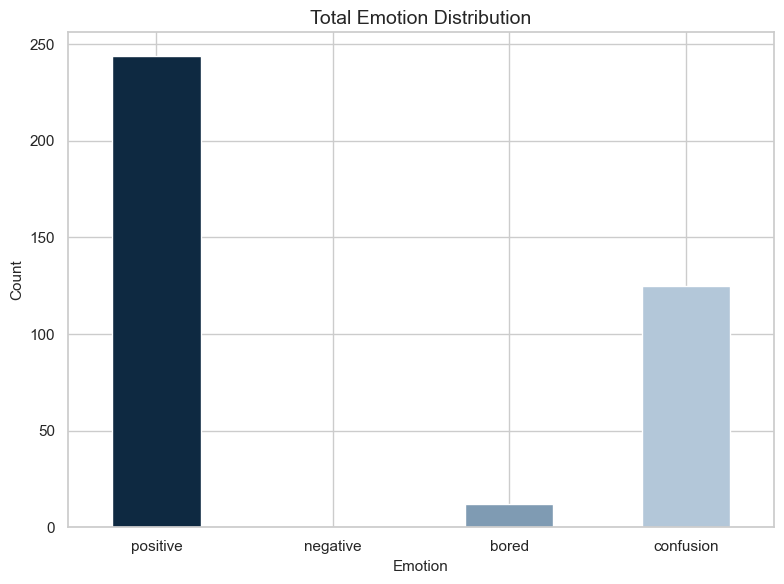

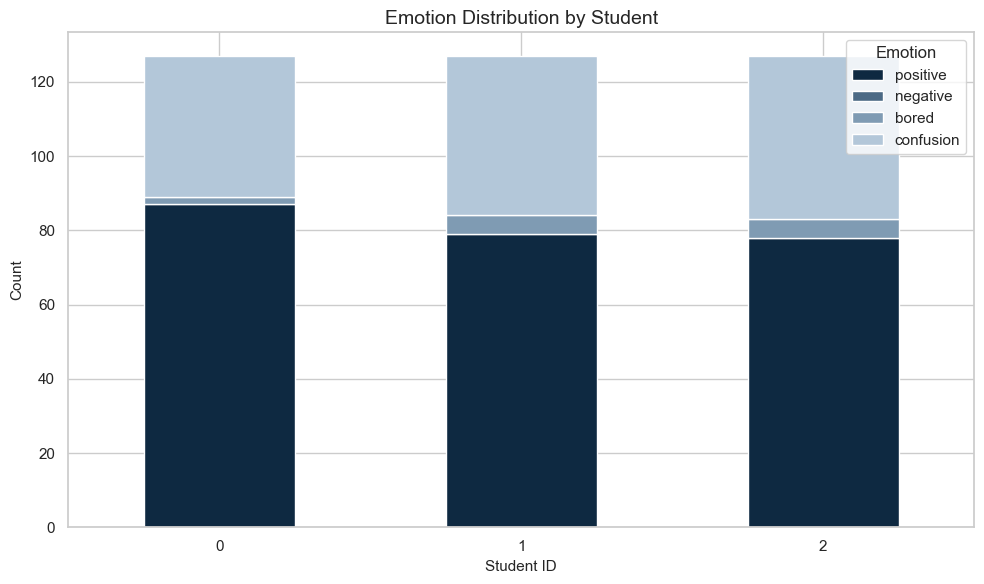

In [5]:
emotion_cols = [col for col in ["positive", "negative", "bored", "confusion"] if col in emotion_df.columns]

if not emotion_cols:
    raise ValueError("No emotion columns found in emotion_df.")

# Total emotion counts
emotion_sums = emotion_df[emotion_cols].sum()

plt.figure(figsize=(8, 6))
emotion_sums.plot(kind="bar", color=PALETTE[:len(emotion_cols)])
plt.title("Total Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(VIS_DIR / "total_emotion_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Emotion by student
if "student_id" in emotion_df.columns:
    emotion_by_student = emotion_df.groupby("student_id")[emotion_cols].sum()

    ax = emotion_by_student.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        color=PALETTE[:len(emotion_cols)]
    )
    plt.title("Emotion Distribution by Student")
    plt.xlabel("Student ID")
    plt.ylabel("Count")
    plt.legend(title="Emotion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(VIS_DIR / "emotion_distribution_by_student.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Summary Scores by Student

Compare each student's attention, engagement, and GD scores.

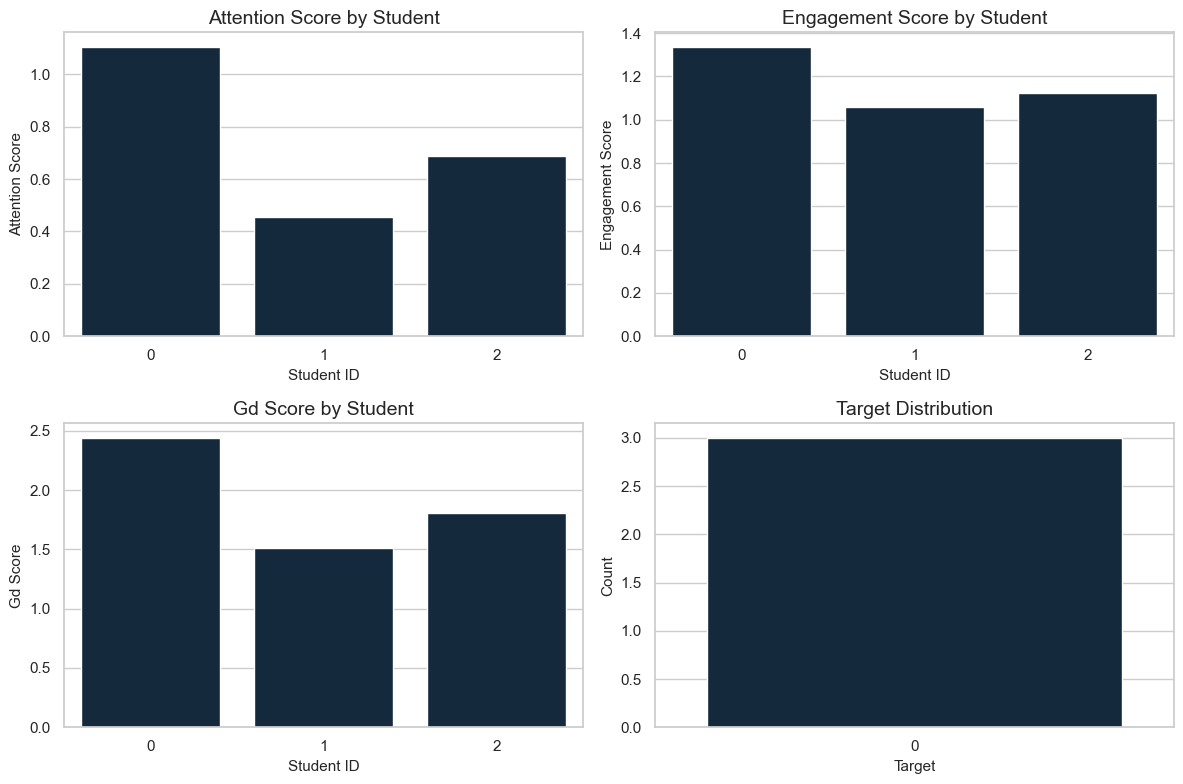

In [6]:
score_cols = [col for col in ["attention_score", "engagement_score", "gd_score"] if col in summary_df.columns]

if "student_id" not in summary_df.columns:
    raise ValueError("summary_df must contain student_id column.")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, col in enumerate(score_cols):
    sns.barplot(data=summary_df, x="student_id", y=col, ax=axes[idx], color=PRIMARY_COLOR)
    axes[idx].set_title(f"{col.replace('_', ' ').title()} by Student")
    axes[idx].set_xlabel("Student ID")
    axes[idx].set_ylabel(col.replace("_", " ").title())

if "target" in summary_df.columns:
    sns.countplot(data=summary_df, x="target", ax=axes[3], color=PRIMARY_COLOR)
    axes[3].set_title("Target Distribution")
    axes[3].set_xlabel("Target")
    axes[3].set_ylabel("Count")
else:
    axes[3].axis("off")

plt.tight_layout()
plt.savefig(VIS_DIR / "summary_scores_by_student.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Score Trends Over Frames

Plot smoothed attention, engagement, and behavior scores over processed frames.

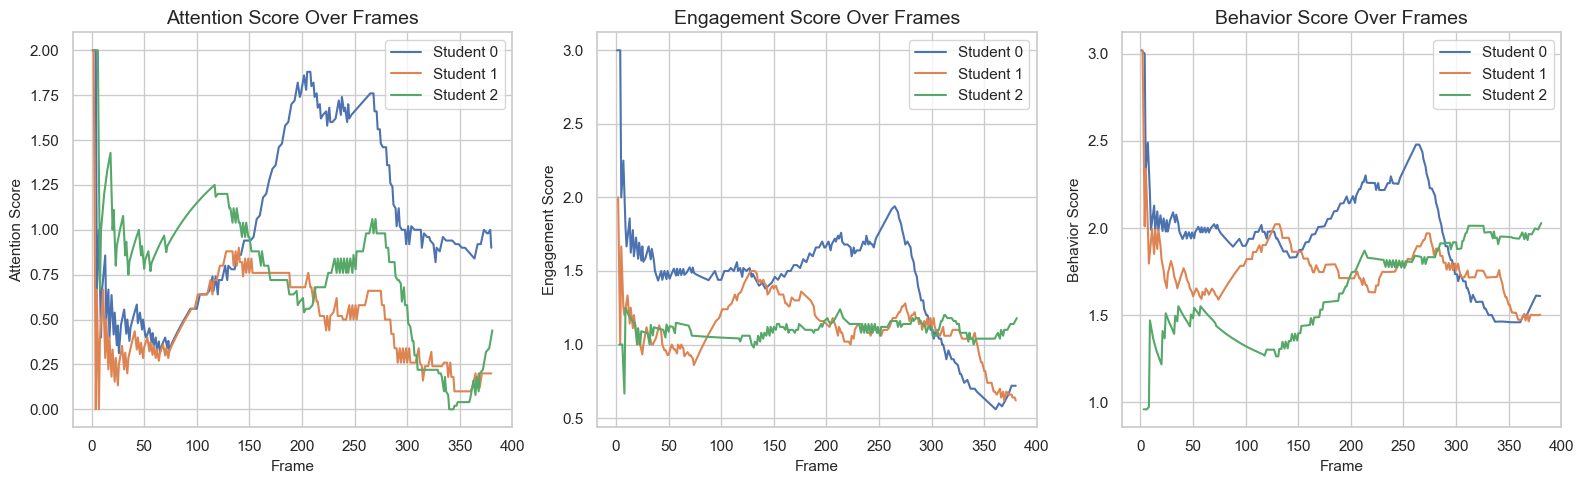

In [7]:
required_trend_cols = ["student_id", "frame", "attention_score", "engagement_score", "behavior_score"]
missing = [col for col in required_trend_cols if col not in final_df.columns]

if missing:
    print(f"Skipping score trend plot. Missing columns: {missing}")
else:
    final_df = final_df.sort_values(["student_id", "frame"]).copy()
    window_size = 50

    for raw_col, smooth_col in [
        ("attention_score", "attention_smooth"),
        ("engagement_score", "engagement_smooth"),
        ("behavior_score", "behavior_smooth"),
    ]:
        final_df[smooth_col] = final_df.groupby("student_id")[raw_col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean()
        )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    plots = [
        ("attention_smooth", "Attention Score Over Frames", "Attention Score"),
        ("engagement_smooth", "Engagement Score Over Frames", "Engagement Score"),
        ("behavior_smooth", "Behavior Score Over Frames", "Behavior Score"),
    ]

    for ax, (col, title, ylabel) in zip(axes, plots):
        for sid in sorted(final_df["student_id"].unique()):
            student_data = final_df[final_df["student_id"] == sid]
            ax.plot(student_data["frame"], student_data[col], label=f"Student {sid}")

        ax.set_title(title)
        ax.set_xlabel("Frame")
        ax.set_ylabel(ylabel)
        ax.legend()

    plt.tight_layout()
    plt.savefig(VIS_DIR / "score_trends_over_frames.png", dpi=300, bbox_inches="tight")
    plt.show()

## 8. Feature Relationship Analysis

Analyze correlations between scores and important behavioral features.

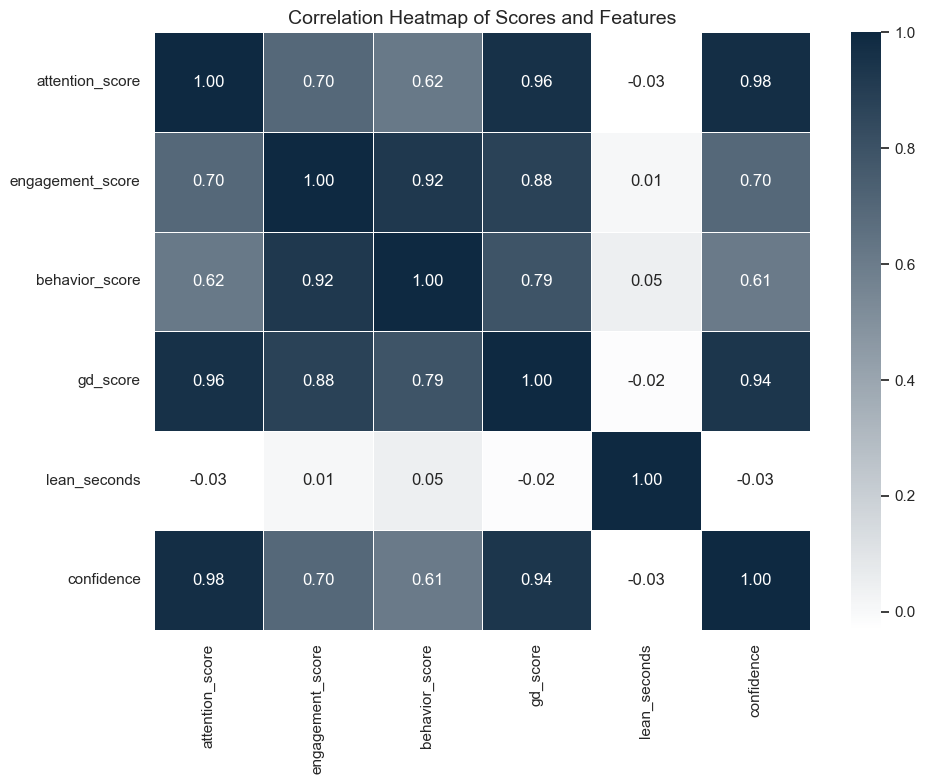

In [8]:
candidate_cols = [
    "attention_score",
    "engagement_score",
    "behavior_score",
    "gd_score",
    "lean_seconds",
    "confidence",
]

numerical_cols = [col for col in candidate_cols if col in final_df.columns]

if len(numerical_cols) < 2:
    print("Not enough numerical columns for correlation analysis.")
else:
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", ["#ffffff", PRIMARY_COLOR])
    corr_df = final_df[numerical_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_df,
        annot=True,
        cmap=custom_cmap,
        fmt=".2f",
        linewidths=0.5,
        cbar=True,
    )
    plt.title("Correlation Heatmap of Scores and Features")
    plt.tight_layout()
    plt.savefig(VIS_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. Pair Plot of Key Scores

Show pairwise relationships between major score columns.

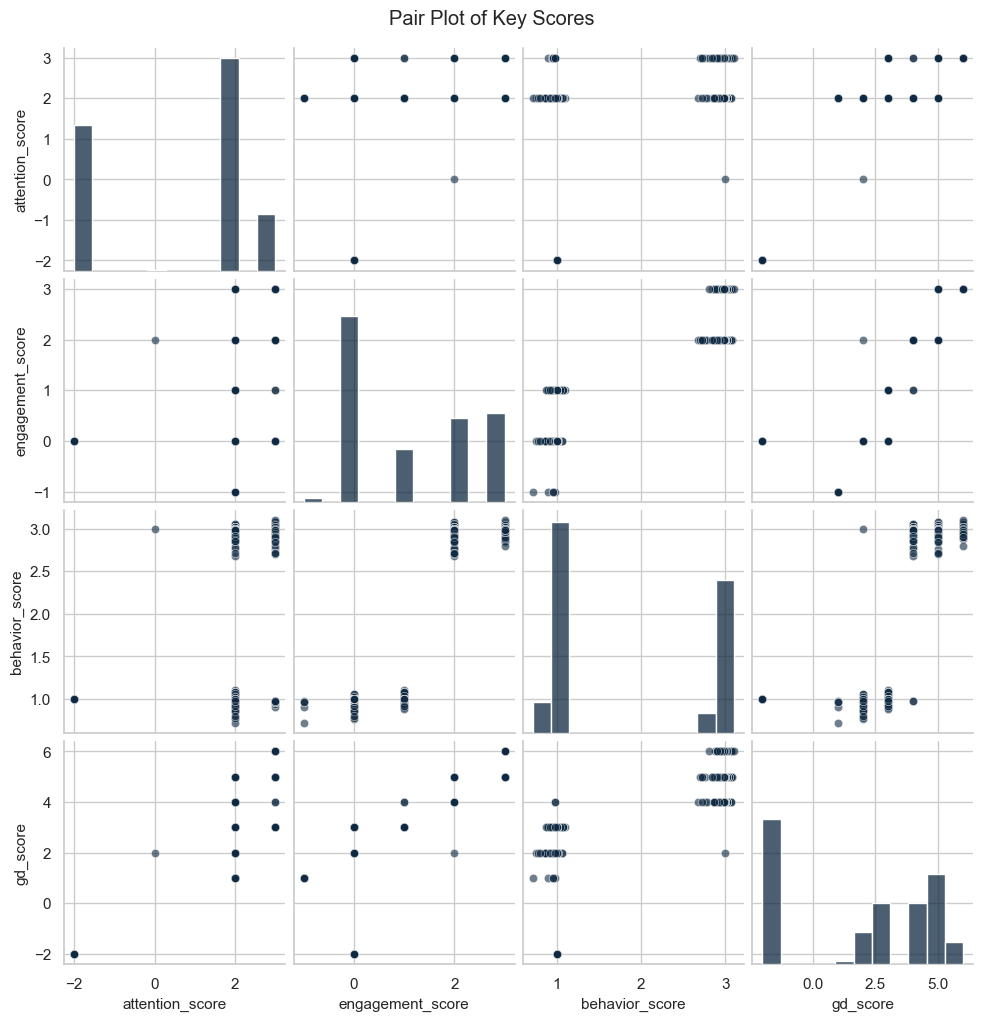

In [9]:
pair_cols = [col for col in ["attention_score", "engagement_score", "behavior_score", "gd_score"] if col in final_df.columns]

if len(pair_cols) < 2:
    print("Not enough score columns for pair plot.")
else:
    pair_grid = sns.pairplot(
        final_df[pair_cols].dropna(),
        diag_kind="hist",
        plot_kws={"alpha": 0.6, "color": PRIMARY_COLOR},
        diag_kws={"color": PRIMARY_COLOR},
    )
    pair_grid.fig.suptitle("Pair Plot of Key Scores", y=1.02)
    pair_grid.savefig(VIS_DIR / "pair_plot_key_scores.png", dpi=300, bbox_inches="tight")
    plt.show()

## 10. Emotion vs Score Box Plots

Compare selected emotion indicators against attention, engagement, and behavior scores.

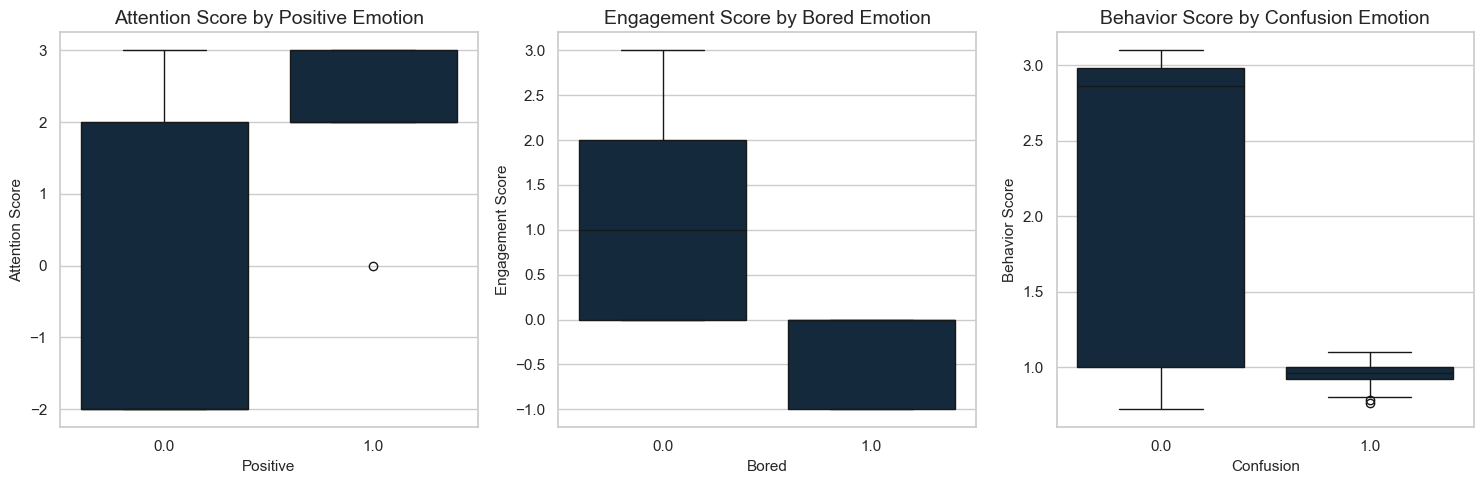

In [10]:
box_specs = [
    ("positive", "attention_score", "Attention Score by Positive Emotion"),
    ("bored", "engagement_score", "Engagement Score by Bored Emotion"),
    ("confusion", "behavior_score", "Behavior Score by Confusion Emotion"),
]

available_specs = [(x, y, title) for x, y, title in box_specs if x in final_df.columns and y in final_df.columns]

if not available_specs:
    print("No matching emotion/score columns available for box plots.")
else:
    fig, axes = plt.subplots(1, len(available_specs), figsize=(5 * len(available_specs), 5))

    if len(available_specs) == 1:
        axes = [axes]

    for ax, (x_col, y_col, title) in zip(axes, available_specs):
        sns.boxplot(data=final_df, x=x_col, y=y_col, ax=ax, color=PRIMARY_COLOR)
        ax.set_title(title)
        ax.set_xlabel(x_col.replace("_", " ").title())
        ax.set_ylabel(y_col.replace("_", " ").title())

    plt.tight_layout()
    plt.savefig(VIS_DIR / "emotion_score_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

## 11. Completion

All visualizations are generated and saved into the visualization output directory.

In [11]:
print("Notebook completed successfully!")
print(f"Saved plots to: {VIS_DIR}")

Notebook completed successfully!
Saved plots to: /Users/sakthiselvi/Documents/Projects/Masters/Course 10 Capstone Project/Student_Behaviour_Analysis/outputs/visualizations
